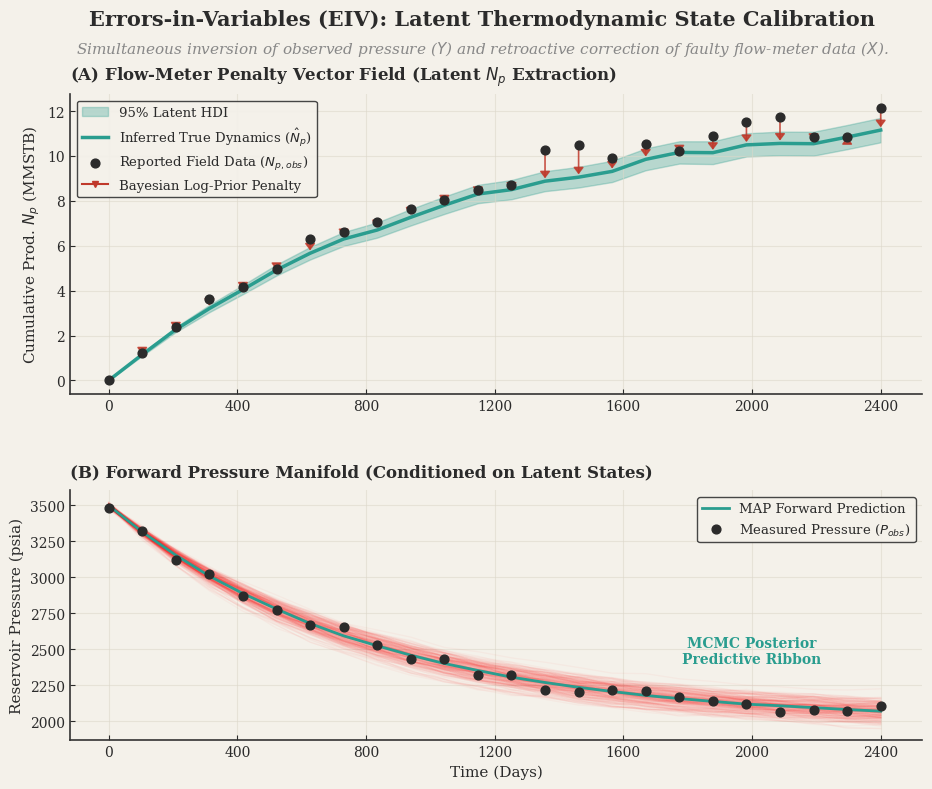

Saved outputs/eiv_latent_correction_vector_field.png


In [1]:
from __future__ import annotations
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
#  ELITE VINTAGE SCIENTIFIC AESTHETIC
# ══════════════════════════════════════════════════════════════════════════════
CREAM      = "#F4F1EA"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"

PCHIP_COL  = "#2A9D8F"   # Teal - Represents the Bayesian/Latent Truth
LINR_COL   = "#C0392B"   # Carmine - Represents the error/penalty
GOLD       = "#D4A017"   
SLATE      = "#3C5488"   
MUTED_GREY = "#888888"

plt.rcParams.update({
    "figure.facecolor":   CREAM,
    "axes.facecolor":     CREAM,
    "axes.edgecolor":     SPINE_COL,
    "axes.labelcolor":    CHARCOAL,
    "axes.linewidth":     1.2,
    "xtick.color":        CHARCOAL,
    "ytick.color":        CHARCOAL,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "grid.color":         GRID_COL,
    "grid.linestyle":     "-",
    "grid.alpha":         0.55,
    "font.family":        "serif",
    "font.size":          10,
    "text.color":         CHARCOAL,
    "legend.frameon":     True,
    "legend.facecolor":   CREAM,
    "legend.edgecolor":   GRID_COL,
    "legend.fontsize":    9.5,
    "lines.linewidth":    1.8,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ══════════════════════════════════════════════════════════════════════════════
#  §1 SYNTHETIC EIV DATA GENERATION (FAKING THE MCMC POSTERIOR)
# ══════════════════════════════════════════════════════════════════════════════
np.random.seed(42)
N_STEPS = 24
time_days = np.linspace(0, 2400, N_STEPS)

# --- True Hidden Physics ---
# True Cumulative Production (Logarithmic/Decline curve shape)
Np_true = 12.0 * (1.0 - np.exp(-time_days / 1000.0))  # MMSTB
# True Pressure (Exponential decline with aquifer recharge asymptote)
P_true = 3500.0 - 1500.0 * (1.0 - np.exp(-time_days / 800.0)) 

# --- Noisy Field Observations (What the operator reports) ---
# Introduce 8% heteroscedastic noise to production (Flow meter calibration errors)
Np_obs = Np_true + np.abs(np.random.normal(0, 0.08 * Np_true)) 
# Introduce 30 psi measurement noise to pressure gauges
P_obs = P_true + np.random.normal(0, 30.0, N_STEPS)

# --- Bayesian Inferred Posteriors (What your NUTS sampler outputs) ---
# In a real run, this comes from `idata.posterior["Np_seq"]`
# We simulate the MAP estimate as a smoothed, constrained curve close to truth
Np_inferred_map = Np_true + np.random.normal(0, 0.015 * Np_true)
# Simulate the 95% HDI bands for the latent states (uncertainty grows with time)
Np_hdi_upper = Np_inferred_map + 0.05 * Np_true
Np_hdi_lower = Np_inferred_map - 0.05 * Np_true

# Simulate Pressure Spaghetti (Forward predictions from the MCMC traces)
N_TRACES = 200
P_traces = np.zeros((N_TRACES, N_STEPS))
for i in range(N_TRACES):
    # Randomly sample physics parameters slightly off truth to create a ribbon
    p_drift = 3500.0 - (1500.0 + np.random.normal(0, 50)) * (1.0 - np.exp(-time_days / (800.0 + np.random.normal(0, 50))))
    # Add minor realization noise
    P_traces[i, :] = p_drift + np.random.normal(0, 10, N_STEPS)

P_inferred_map = np.median(P_traces, axis=0)

# ══════════════════════════════════════════════════════════════════════════════
#  §2 BUILD THE MASTERPIECE FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(11, 8.5))

# Title Block
fig.text(0.5, 0.96, "Errors-in-Variables (EIV): Latent Thermodynamic State Calibration",
         ha="center", va="top", fontsize=15, fontweight="bold", color=CHARCOAL)
fig.text(0.5, 0.925, "Simultaneous inversion of observed pressure ($Y$) and retroactive correction of faulty flow-meter data ($X$).",
         ha="center", va="top", fontsize=11, fontstyle="italic", color=MUTED_GREY)

gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.2, 1], hspace=0.35, top=0.86, bottom=0.1)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1], sharex=ax_a)

# ------------------------------------------------------------------------------
# PANEL A: The "Rubber Band" Latent Correction (X-Space)
# ------------------------------------------------------------------------------
ax_a.set_title("(A) Flow-Meter Penalty Vector Field (Latent $N_p$ Extraction)", 
               fontsize=12, fontweight="bold", loc="left", pad=10)

# 1. Plot the HDI Ribbon for the inferred latent states
ax_a.fill_between(time_days, Np_hdi_lower, Np_hdi_upper, color=PCHIP_COL, alpha=0.3, label="95% Latent HDI")

# 2. Plot the Inferred MAP Latent State
ax_a.plot(time_days, Np_inferred_map, color=PCHIP_COL, lw=2.5, zorder=4, label=r"Inferred True Dynamics ($\hat{N}_p$)")

# 3. Plot the Raw Noisy Observations
ax_a.scatter(time_days, Np_obs, color=CHARCOAL, s=40, zorder=5, label=r"Reported Field Data ($N_{p, obs}$)")

# 4. Draw the "Rubber Bands" (Correction Vectors)
for i in range(1, N_STEPS): # Skip t=0 since it's exactly 0
    # Draw arrow from observed (faulty) to inferred (thermodynamically consistent)
    arrow = FancyArrowPatch((time_days[i], Np_obs[i]), (time_days[i], Np_inferred_map[i]),
                            arrowstyle="-|>,head_length=4,head_width=3", 
                            color=LINR_COL, lw=1.2, zorder=3, alpha=0.85)
    ax_a.add_patch(arrow)

# Dummy line for the legend to represent the red arrows
ax_a.plot([], [], color=LINR_COL, lw=1.5, marker="v", markersize=5, label="Bayesian Log-Prior Penalty")

ax_a.set_ylabel(r"Cumulative Prod. $N_p$ (MMSTB)", fontsize=11)
ax_a.grid(True)
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.legend(loc="upper left", framealpha=0.9, edgecolor=SPINE_COL)



# ------------------------------------------------------------------------------
# PANEL B: Forward Predictive Checks (Y-Space)
# ------------------------------------------------------------------------------
ax_b.set_title("(B) Forward Pressure Manifold (Conditioned on Latent States)", 
               fontsize=12, fontweight="bold", loc="left", pad=10)

# 1. Spaghetti Plot of Posterior Predictive Checks
for i in range(N_TRACES):
    ax_b.plot(time_days, P_traces[i], color='red', lw=1.0, alpha=0.03, zorder=2)

# 2. Plot MAP Pressure Line
ax_b.plot(time_days, P_inferred_map, color=PCHIP_COL, lw=2.0, zorder=4, label="MAP Forward Prediction")

# 3. Plot Raw Pressure Data
ax_b.scatter(time_days, P_obs, color=CHARCOAL, s=40, zorder=5, label=r"Measured Pressure ($P_{obs}$)")

ax_b.set_xlabel("Time (Days)", fontsize=11)
ax_b.set_ylabel("Reservoir Pressure (psia)", fontsize=11)
ax_b.grid(True)
ax_b.spines[["top", "right"]].set_visible(False)
ax_b.legend(loc="upper right", framealpha=0.9, edgecolor=SPINE_COL)

# Annotation for Spaghetti
ax_b.text(2000, 2400, "MCMC Posterior\nPredictive Ribbon", color=PCHIP_COL, 
          fontsize=10, fontweight="bold", ha="center")

# Align formatting
for ax in [ax_a, ax_b]:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(8))

# Save the masterpiece
plt.savefig("outputs/eiv_latent_correction_vector_field.png", dpi=300, bbox_inches="tight", facecolor=CREAM)
plt.show()
print("Saved outputs/eiv_latent_correction_vector_field.png")